<a href="https://colab.research.google.com/github/varun1271/DSA0203-COMPUTER-VISION/blob/main/COMPUTER_VISION_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
EXP-1

Saving WhatsApp Image 2026-07-21 at 1.52.57 PM.jpeg to WhatsApp Image 2026-07-21 at 1.52.57 PM (4).jpeg


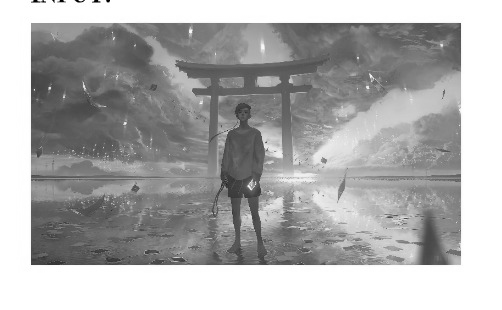

True

In [8]:
from google.colab import files#1
from google.colab.patches import cv2_imshow
import cv2

uploaded = files.upload()
img = cv2.imread(next(iter(uploaded)))

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)
cv2.imwrite("gray_image.jpg", gray)

In [ ]:
EXP-2

Saving WhatsApp Image 2026-07-21 at 1.52.57 PM.jpeg to WhatsApp Image 2026-07-21 at 1.52.57 PM (5).jpeg


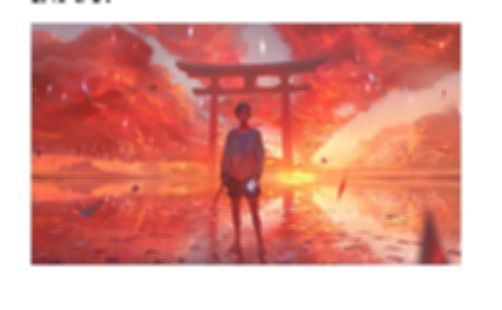

True

In [9]:
from google.colab import files
from google.colab.patches import cv2_imshow
import cv2

uploaded = files.upload()
img = cv2.imread(next(iter(uploaded)))

blur = cv2.GaussianBlur(img, (5,5), 10)
cv2_imshow(blur)
cv2.imwrite("blurred_image.jpg", blur)

In [ ]:
EXP-3

Saving WhatsApp Image 2026-07-21 at 1.52.57 PM.jpeg to WhatsApp Image 2026-07-21 at 1.52.57 PM (6).jpeg


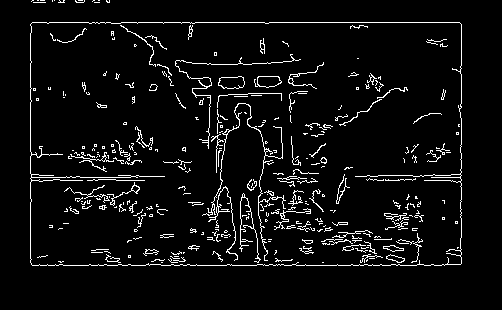

True

In [10]:
from google.colab import files
from google.colab.patches import cv2_imshow
import cv2

uploaded = files.upload()
img = cv2.imread(next(iter(uploaded)))

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 100, 200)

cv2_imshow(edges)
cv2.imwrite("canny_edges.jpg", edges)

In [ ]:
EXP-4

Saving WhatsApp Image 2026-07-21 at 1.52.57 PM.jpeg to WhatsApp Image 2026-07-21 at 1.52.57 PM (7).jpeg


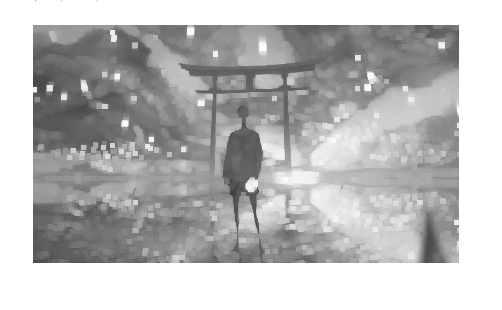

True

In [11]:
from google.colab import files
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

uploaded = files.upload()
img = cv2.imread(next(iter(uploaded)), 0)

kernel = np.ones((5,5), np.uint8)
dilate = cv2.dilate(img, kernel, iterations=1)

cv2_imshow(dilate)
cv2.imwrite("dilated_image.jpg", dilate)

In [ ]:
EXP-5

Saving WhatsApp Image 2026-07-21 at 1.52.57 PM.jpeg to WhatsApp Image 2026-07-21 at 1.52.57 PM (8).jpeg


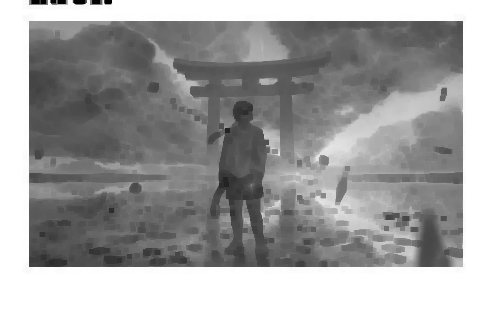

True

In [12]:
from google.colab import files
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

uploaded = files.upload()
img = cv2.imread(next(iter(uploaded)), 0)

kernel = np.ones((5,5), np.uint8)
erode = cv2.erode(img, kernel, iterations=1)

cv2_imshow(erode)
cv2.imwrite("eroded_image.jpg", erode)

In [ ]:
exp-6

In [ ]:
import cv2
import os
from google.colab.patches import cv2_imshow

# -------------------------------
# Create folders
# -------------------------------
os.makedirs("frames", exist_ok=True)

# -------------------------------
# Load Video
# -------------------------------
cap = cv2.VideoCapture("/content/V_992.mp4")

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# -------------------------------
# Output Videos
# -------------------------------
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

violence_video = cv2.VideoWriter(
    "violence_output.mp4",
    fourcc,
    fps,
    (width, height)
)

nonviolence_video = cv2.VideoWriter(
    "non_violence_output.mp4",
    fourcc,
    fps,
    (width, height)
)

# -------------------------------
# Person Detector
# -------------------------------
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

frame_id = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_id += 1

    # -------------------------
    # Save Frame
    # -------------------------
    cv2.imwrite(f"frames/frame_{frame_id:04d}.jpg", frame)

    # -------------------------
    # Detect Persons
    # -------------------------
    boxes, weights = hog.detectMultiScale(
        frame,
        winStride=(8,8),
        padding=(8,8),
        scale=1.05
    )

    count = 0

    for (x,y,w,h) in boxes:

        count += 1

        cv2.rectangle(
            frame,
            (x,y),
            (x+w,y+h),
            (0,255,0),
            2
        )

    # -------------------------
    # Violence Logic
    # -------------------------
    if count >= 2:

        cv2.putText(
            frame,
            "Violence Detected",
            (20,40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0,0,255),
            2
        )

        violence_video.write(frame)

    else:

        cv2.putText(
            frame,
            "No Violence",
            (20,40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0,255,0),
            2
        )

        nonviolence_video.write(frame)

    cv2_imshow(frame)

    # Removed cv2.waitKey(25) as it's not compatible with cv2_imshow in Colab.

cap.release()

violence_video.release()
nonviolence_video.release()

cv2.destroyAllWindows()

print("Frames Saved Successfully")
print("Violence Video Saved")
print("Non-Violence Video Saved")

In [ ]:
EXP-7

Saving WhatsApp Image 2026-07-21 at 1.52.57 PM.jpeg to WhatsApp Image 2026-07-21 at 1.52.57 PM.jpeg
Original Image


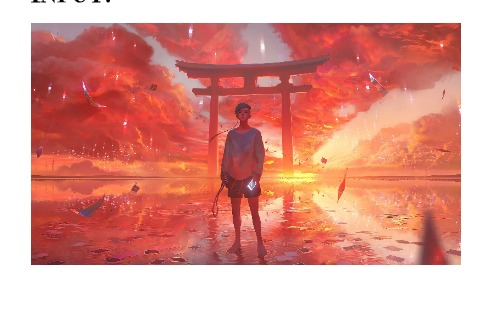

Clockwise Rotated Image


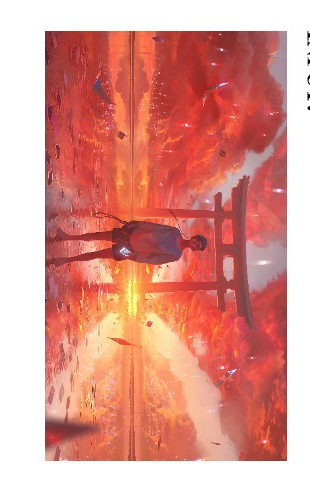

Counterclockwise Rotated Image


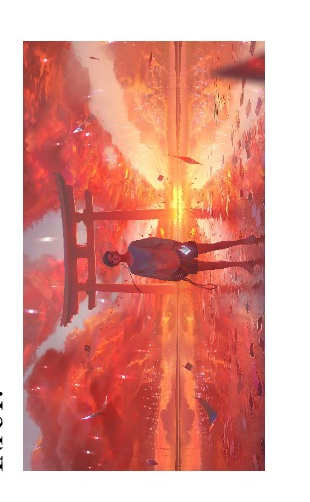

Images saved successfully.


In [2]:
from google.colab import files
from google.colab.patches import cv2_imshow
import cv2

# Upload image
uploaded = files.upload()

# Read uploaded image
img = cv2.imread(next(iter(uploaded)))

# Rotate 90° clockwise
clockwise = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

# Rotate 90° counterclockwise
counterclockwise = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)

# Display images
print("Original Image")
cv2_imshow(img)

print("Clockwise Rotated Image")
cv2_imshow(clockwise)

print("Counterclockwise Rotated Image")
cv2_imshow(counterclockwise)

# Save images
cv2.imwrite("Clockwise_Image.jpg", clockwise)
cv2.imwrite("Counterclockwise_Image.jpg", counterclockwise)

print("Images saved successfully.")

In [ ]:
EXP-8

Saving WhatsApp Image 2026-07-21 at 1.52.57 PM.jpeg to WhatsApp Image 2026-07-21 at 1.52.57 PM (1).jpeg
Original Image


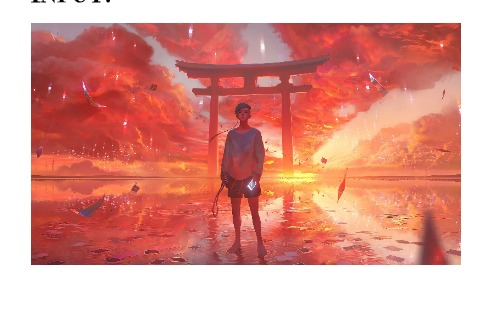

Bigger Image


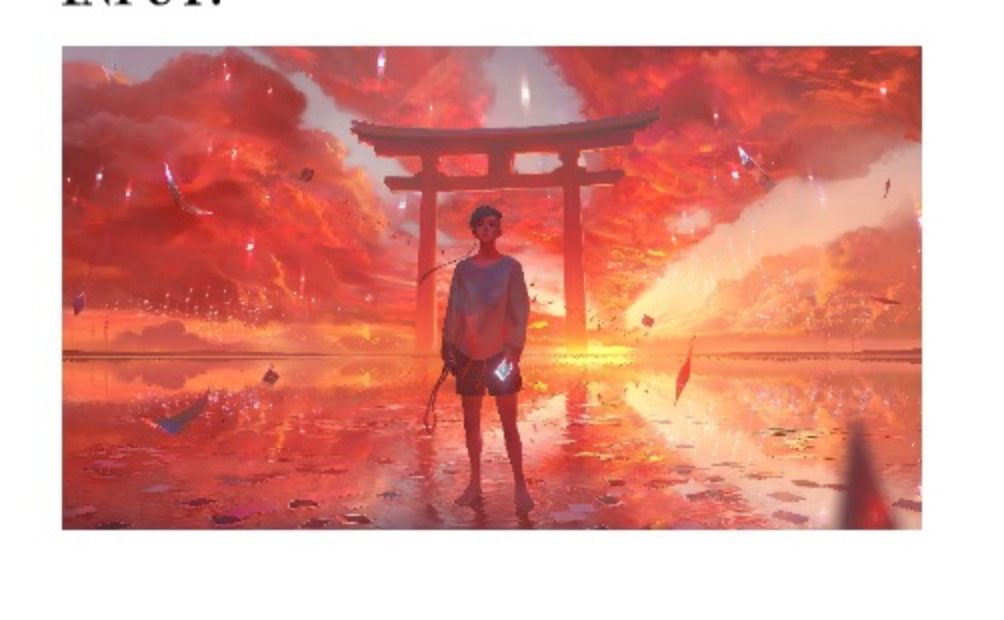

Smaller Image


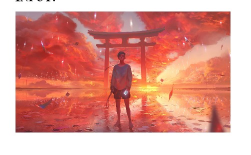

Images saved successfully.


In [3]:
from google.colab import files
from google.colab.patches import cv2_imshow
import cv2

# Upload image
uploaded = files.upload()

# Read uploaded image
image = cv2.imread(next(iter(uploaded)))

if image is None:
    print("Unable to read image")
else:
    # Bigger image (2x)
    bigger = cv2.resize(image, None, fx=2, fy=2)

    # Smaller image (0.5x)
    smaller = cv2.resize(image, None, fx=0.5, fy=0.5)

    # Display images
    print("Original Image")
    cv2_imshow(image)

    print("Bigger Image")
    cv2_imshow(bigger)

    print("Smaller Image")
    cv2_imshow(smaller)

    # Save images
    cv2.imwrite("Bigger_Image.jpg", bigger)
    cv2.imwrite("Smaller_Image.jpg", smaller)

    print("Images saved successfully.")

In [ ]:
EXP-9

Saving WhatsApp Image 2026-07-21 at 1.52.57 PM.jpeg to WhatsApp Image 2026-07-21 at 1.52.57 PM (2).jpeg
Original Image


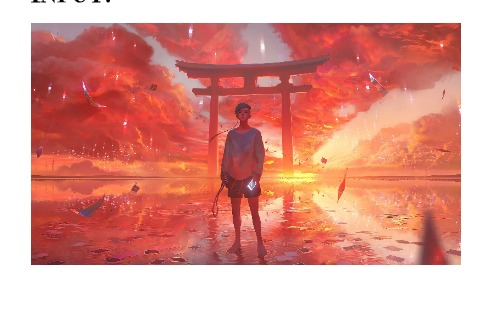

Affine Transformed Image


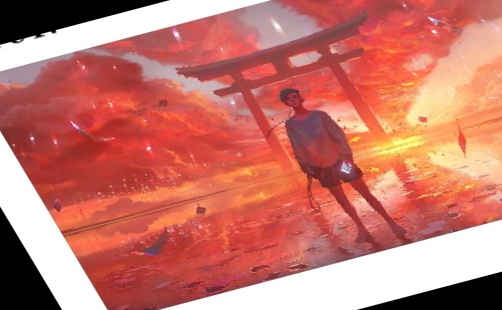

Image saved successfully.


In [4]:
from google.colab import files
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

# Upload image
uploaded = files.upload()

# Read uploaded image
img = cv2.imread(next(iter(uploaded)))

rows, cols = img.shape[:2]

# Define three points for affine transformation
pts1 = np.float32([[50, 50], [200, 50], [50, 200]])
pts2 = np.float32([[10, 100], [200, 50], [100, 250]])

# Get transformation matrix
matrix = cv2.getAffineTransform(pts1, pts2)

# Apply affine transformation
result = cv2.warpAffine(img, matrix, (cols, rows))

# Display images
print("Original Image")
cv2_imshow(img)

print("Affine Transformed Image")
cv2_imshow(result)

# Save transformed image
cv2.imwrite("Affine_Image.jpg", result)

print("Image saved successfully.")

In [ ]:
EXP-10

Saving WhatsApp Image 2026-07-21 at 1.52.57 PM.jpeg to WhatsApp Image 2026-07-21 at 1.52.57 PM (3).jpeg
Original Image


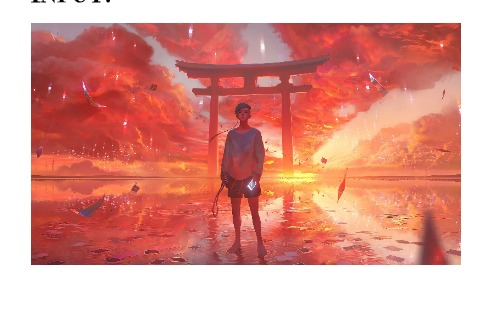

Perspective Transformed Image


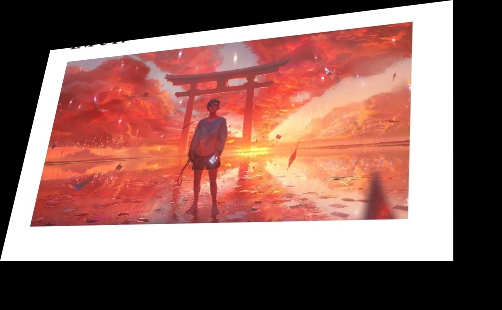

Image saved successfully.


In [5]:
from google.colab import files
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

# Upload image
uploaded = files.upload()

# Read uploaded image
img = cv2.imread(next(iter(uploaded)))

rows, cols = img.shape[:2]

# Define four points for perspective transformation
pts1 = np.float32([[0, 0], [cols-1, 0], [0, rows-1], [cols-1, rows-1]])
pts2 = np.float32([[50, 50], [cols-50, 0], [0, rows-50], [cols-50, rows-50]])

# Get perspective transformation matrix
matrix = cv2.getPerspectiveTransform(pts1, pts2)

# Apply perspective transformation
result = cv2.warpPerspective(img, matrix, (cols, rows))

# Display images
print("Original Image")
cv2_imshow(img)

print("Perspective Transformed Image")
cv2_imshow(result)

# Save transformed image
cv2.imwrite("Perspective_Image.jpg", result)

print("Image saved successfully.")